<a href="https://colab.research.google.com/github/felicity8899/ds-classes/blob/main/deeplearningP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# 1. Set seed for reproducibility
torch.manual_seed(42)

# 2. Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 20
HIDDEN_SIZES = [128, 64]
DROPOUT_RATE = 0.2

In [ ]:
# 3. Data Preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

In [ ]:
# Load Datasets
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Starting Training...
Epoch [1/20], Loss: 0.5863
Epoch [2/20], Loss: 0.4348
Epoch [3/20], Loss: 0.4000
Epoch [4/20], Loss: 0.3752
Epoch [5/20], Loss: 0.3565
Epoch [6/20], Loss: 0.3454
Epoch [7/20], Loss: 0.3322
Epoch [8/20], Loss: 0.3234
Epoch [9/20], Loss: 0.3151
Epoch [10/20], Loss: 0.3110
Epoch [11/20], Loss: 0.3042
Epoch [12/20], Loss: 0.2970
Epoch [13/20], Loss: 0.2943
Epoch [14/20], Loss: 0.2898
Epoch [15/20], Loss: 0.2853
Epoch [16/20], Loss: 0.2803
Epoch [17/20], Loss: 0.2772
Epoch [18/20], Loss: 0.2704
Epoch [19/20], Loss: 0.2706
Epoch [20/20], Loss: 0.2694

Final Test Accuracy: 88.66%


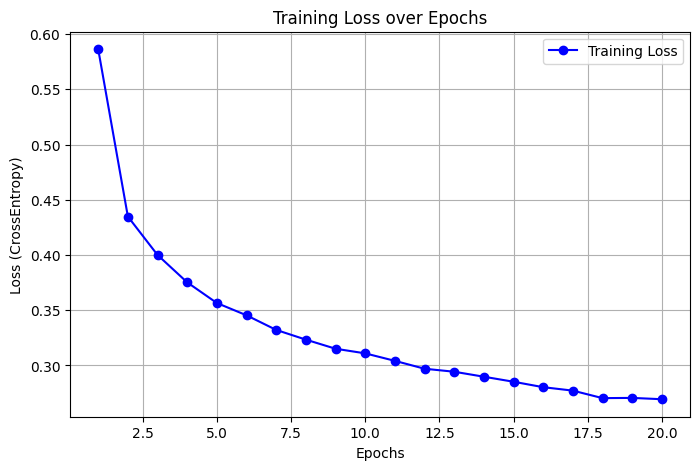

In [ ]:
# 4. Model Architecture
class FashionMLP(nn.Module):
    def __init__(self):
        super(FashionMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, HIDDEN_SIZES[0]),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(HIDDEN_SIZES[0], HIDDEN_SIZES[1]),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(HIDDEN_SIZES[1], 10) # 10 classes
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FashionMLP().to(device)

# 5. Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 6. Training Loop
train_losses = []

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss:.4f}")

# 7. Evaluation
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f"\nFinal Test Accuracy: {accuracy:.2f}%")

# 8. Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='b', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (CrossEntropy)')
plt.grid(True)
plt.legend()

In [ ]:
CHECKPOINT_PATH = 'mlp_checkpoint.pth'
checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss,
            'train_losses': train_losses,
            'accuracy': accuracy,
            'all_preds': all_preds,
            'all_labels': all_labels
            }
torch.save(checkpoint, CHECKPOINT_PATH)
